# **DATA UNDERSTANDING**

This notebook focuses on the initial data understanding phase of the KKBox churn prediction project.

The goal is to explore the structure, quality, and main characteristics of each dataset in order to identify potential issues and understand the data before preprocessing.

No transformations are applied at this stage.


## 1.  IMPORTS

In [28]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. DATA LOADING

### 2.1. TRAIN INITIAL EDA

In [29]:
# 1. Load train_v2.csv dataset
train = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/train_v2.csv")

In [30]:
# 2. Dataset Structure
print("Dataset info:")
train.info()
print(f"\nDataset shape: {train.shape}")
print(f"\nDataset columns: {list(train.columns)}")
print(f"\nDataset datatypes:\n{train.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(train.nunique())

# print first few rows of the dataset
train.head()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      970960 non-null  object
 1   is_churn  970960 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 14.8+ MB

Dataset shape: (970960, 2)

Dataset columns: ['msno', 'is_churn']

Dataset datatypes:
msno        object
is_churn     int64
dtype: object

Number of unique values in each column:
msno        970960
is_churn         2
dtype: int64


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


In [31]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(train.isnull().sum())

# check percentage of missing values in each column
print(f"\nPercentage of missing values in each column:")
print((train.isnull().sum() / len(train) * 100).round(2
))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {train['msno'].duplicated().sum()}")



Number of missing values in each column:
msno        0
is_churn    0
dtype: int64

Percentage of missing values in each column:
msno        0.0
is_churn    0.0
dtype: float64

Duplicated values in msno column: 0


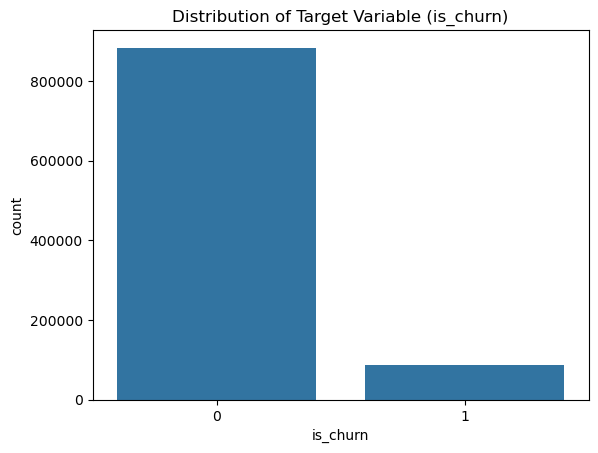


The target variable is imbalanced.
Percentage of churned customers: 8.99%


In [32]:
# 4. Target Variable Distribution
sns.countplot(x='is_churn', data=train)
plt.title("Distribution of Target Variable (is_churn)")
plt.show()

if train['is_churn'].value_counts().min() / train['is_churn'].value_counts().max() < 0.5:
    print("\nThe target variable is imbalanced.")
else:
    print("\nThe target variable is balanced.")

# print percentage of churned customers 
churn_percentage = train['is_churn'].mean() * 100
print(f"Percentage of churned customers: {churn_percentage:.2f}%")

### 2.2. MEMBERS INITIAL EDA

In [33]:
# 1. Load members_v3.csv dataset
members = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/members_v3.csv")   


In [38]:

# 2. Dataset Structure
print("Dataset info:")
members.info()

print(f"\nDataset shape: {members.shape}")

print(f"\nDataset columns: {list(members.columns)}")

print(f"\nDataset datatypes:\n{members.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(members.nunique())

# identify numerical and categorical columns
numerical_cols = members.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = members.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {list(numerical_cols)}")
print(f"\nCategorical columns: {list(categorical_cols)}")

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
members.head()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   msno                    object
 1   city                    int64 
 2   bd                      int64 
 3   gender                  object
 4   registered_via          int64 
 5   registration_init_time  int64 
dtypes: int64(4), object(2)
memory usage: 309.9+ MB

Dataset shape: (6769473, 6)

Dataset columns: ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']

Dataset datatypes:
msno                      object
city                       int64
bd                         int64
gender                    object
registered_via             int64
registration_init_time     int64
dtype: object

Number of unique values in each column:
msno                      6769473
city                           21
bd                            386
gender                          2
r

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [42]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(members.isnull().sum())

# check percentage of missing values in each column
print("\nPercentage of missing values in each column:")
print((members.isnull().sum() / len(members) * 100).round(2))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {members['msno'].duplicated().sum()}")

# check for duplicated rows
print(f"\nDuplicated rows in dataset: {members.duplicated().sum()}")

# statistical summary only for true numerical variables
print("\nStatistical summary (numerical variables only):")
print(members[['bd']].describe())

# check min and max values for key columns
print("\nMin and max values:")
print(members[['bd']].agg(['min', 'max']))




Number of missing values in each column:
msno                            0
city                            0
bd                              0
gender                    4429505
registered_via                  0
registration_init_time          0
dtype: int64

Percentage of missing values in each column:
msno                       0.00
city                       0.00
bd                         0.00
gender                    65.43
registered_via             0.00
registration_init_time     0.00
dtype: float64

Duplicated values in msno column: 0

Duplicated rows in dataset: 0

Statistical summary (numerical variables only):
                 bd
count  6.769473e+06
mean   9.795794e+00
std    1.792590e+01
min   -7.168000e+03
25%    0.000000e+00
50%    0.000000e+00
75%    2.100000e+01
max    2.016000e+03

Min and max values:
       bd
min -7168
max  2016



Gender distribution:
gender
NaN       4429505
male      1195355
female    1144613
Name: count, dtype: int64

City distribution (top 10):
city
1     4804326
5      385069
13     320978
4      246848
22     210407
15     190213
6      135200
14      89940
12      66843
9       47639
Name: count, dtype: int64

Registered via distribution:
registered_via
 4     2793213
 3     1643208
 9     1482863
 7      805895
 11      25047
 13       5455
 8        3982
 5        3115
 17       1494
 2        1452
 6        1213
 19        974
 16        888
 14        615
 1          43
 10         10
 18          5
-1           1
Name: count, dtype: int64


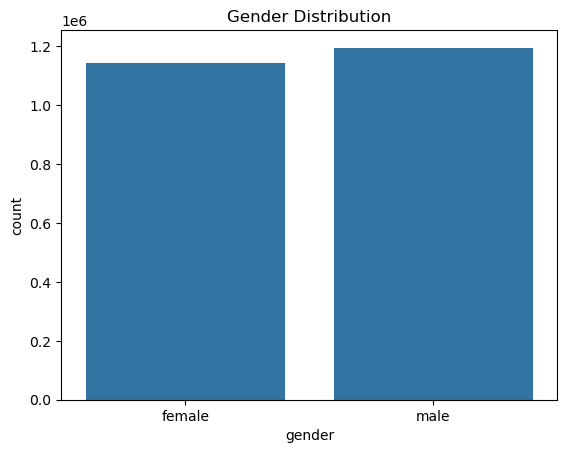

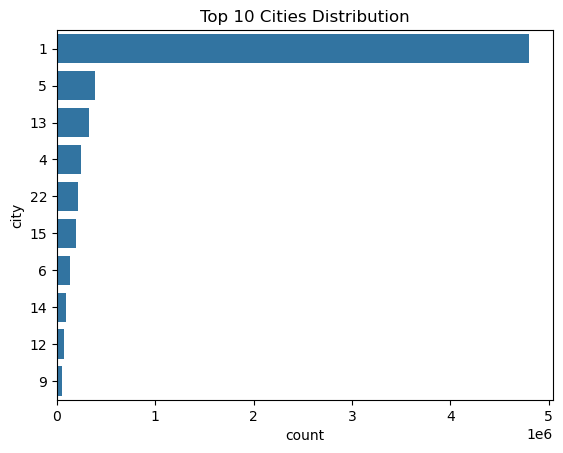

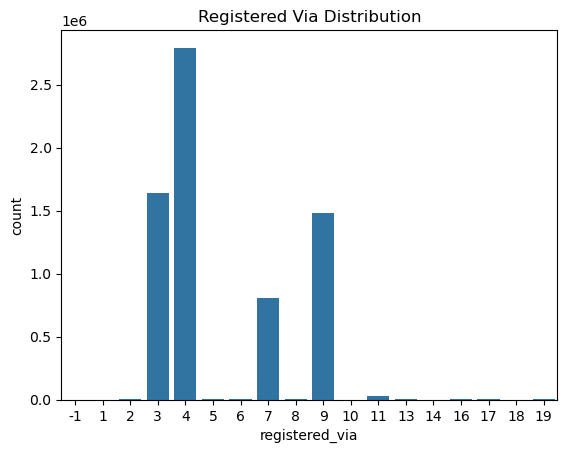

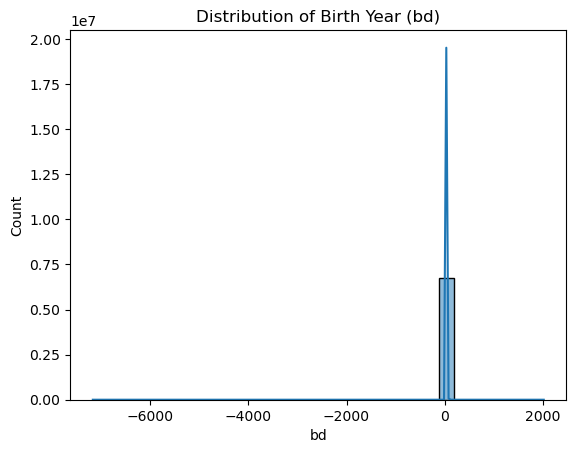

In [52]:
# 4. Key Variables Distribution 

# Categorical variables distribution

# print gender distribution
print("\nGender distribution:")
print(members['gender'].value_counts(dropna=False))

# print city distribution (top 10)
print("\nCity distribution (top 10):")
print(members['city'].value_counts().head(10))

# print registered via distribution
print("\nRegistered via distribution:")
print(members['registered_via'].value_counts())

# plot gender distribution
sns.countplot(x='gender', data=members)
plt.title("Gender Distribution")
plt.show()

# plot city distribution (top 10)
top_cities = members['city'].value_counts().head(10).index
sns.countplot(y='city', data=members[members['city'].isin(top_cities)], order=top_cities)
plt.title("Top 10 Cities Distribution")
plt.show()

# plot registered via distribution
sns.countplot(x='registered_via', data=members)
plt.title("Registered Via Distribution")
plt.show()

# numerical variables distribution
# plot distribution of birth year (bd)
sns.histplot(members['bd'], bins=30, kde=True)
plt.title("Distribution of Birth Year (bd)")
plt.show()

Members Initial EDA Note: age looks strange (many 0, negative and large values); gender has many missing values (~65%); user id seems unique; registration date is not in datetime format; some numeric columns represent categories and will be treated as categorical variables.

### 2.3. TRANSACTIONS INITIAL EDA

In [47]:
# 1. Load transactions_v2.csv dataset
transactions = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/transactions_v2.csv") 

In [51]:
# 2. Dataset Structure
print("Dataset info:")
transactions.info()

print(f"\nDataset shape: {transactions.shape}")

print(f"\nDataset columns: {list(transactions.columns)}")

print(f"\nDataset datatypes:\n{transactions.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(transactions.nunique())

# print dataset unique values per column
print("\nUnique values in each column:")
for col in transactions.columns:
    unique_values = transactions[col].unique()
    print(f"{col}: {unique_values[:5]}{'...' if len(unique_values) > 5 else ''}")

# identify numerical and categorical columns
numerical_cols = transactions.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = transactions.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {list(numerical_cols)}")
print(f"\nCategorical columns: {list(categorical_cols)}")

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
members.head()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   msno                    1431009 non-null  object
 1   payment_method_id       1431009 non-null  int64 
 2   payment_plan_days       1431009 non-null  int64 
 3   plan_list_price         1431009 non-null  int64 
 4   actual_amount_paid      1431009 non-null  int64 
 5   is_auto_renew           1431009 non-null  int64 
 6   transaction_date        1431009 non-null  int64 
 7   membership_expire_date  1431009 non-null  int64 
 8   is_cancel               1431009 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 98.3+ MB

Dataset shape: (1431009, 9)

Dataset columns: ['msno', 'payment_method_id', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'transaction_date', 'membership_expire_date', 'is_cancel']

Dataset datat

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [54]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(transactions.isnull().sum())

# check percentage of missing values in each column
print("\nPercentage of missing values in each column:")
print((transactions.isnull().sum() / len(transactions) * 100).round(2))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {transactions['msno'].duplicated().sum()}")

# check for duplicated rows
print(f"\nDuplicated rows in dataset: {transactions.duplicated().sum()}")

# statistical summary only for true numerical variables
numerical_cols = ['payment_plan_days', 'plan_list_price', 'actual_amount_paid']

print("\nStatistical summary (numerical variables only):")
print(transactions[numerical_cols].describe())

# check min and max values for key columns
print("\nMin and max values:")
print(transactions[numerical_cols].agg(['min', 'max']))



Number of missing values in each column:
msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64

Percentage of missing values in each column:
msno                      0.0
payment_method_id         0.0
payment_plan_days         0.0
plan_list_price           0.0
actual_amount_paid        0.0
is_auto_renew             0.0
transaction_date          0.0
membership_expire_date    0.0
is_cancel                 0.0
dtype: float64

Duplicated values in msno column: 233959

Duplicated rows in dataset: 0

Statistical summary (numerical variables only):
       payment_plan_days  plan_list_price  actual_amount_paid
count       1.431009e+06     1.431009e+06        1.431009e+06
mean        6.601770e+01     2.817870e+02        2.813172e+02
std         1.024864e+02     4.351861e+02        4.354


Cancellation distribution:
is_cancel
0    1395876
1      35133
Name: count, dtype: int64

Auto-renew distribution:
is_auto_renew
1    1123775
0     307234
Name: count, dtype: int64

Payment method distribution (top 10):
payment_method_id
41    696696
39    137120
38    115875
32    100982
36     90844
40     82747
37     40414
34     31099
29     24957
30     21182
Name: count, dtype: int64


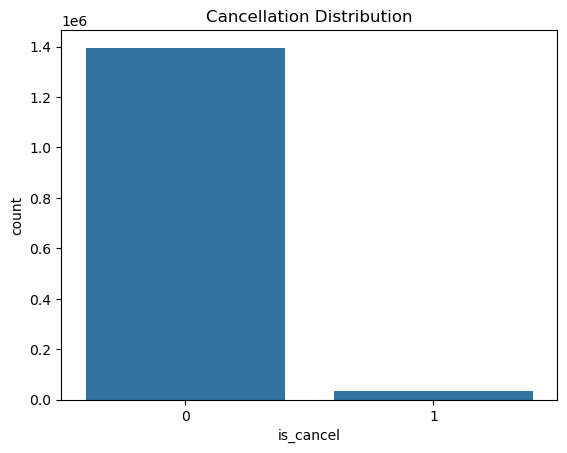

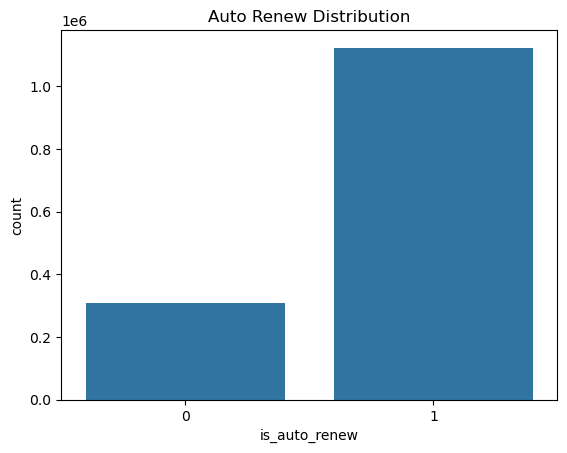

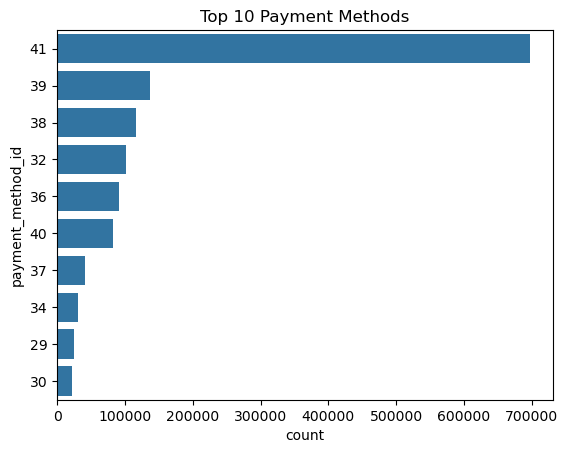


Payment plan days distribution:

Plan list price distribution:
count    1.431009e+06
mean     2.817870e+02
std      4.351861e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: plan_list_price, dtype: float64

Actual amount paid distribution:
count    1.431009e+06
mean     2.813172e+02
std      4.354200e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: actual_amount_paid, dtype: float64


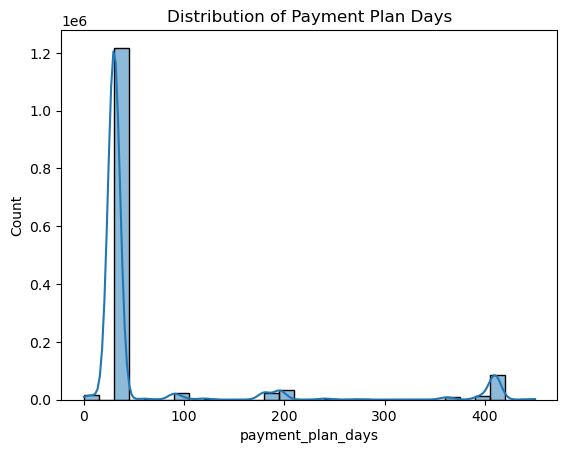

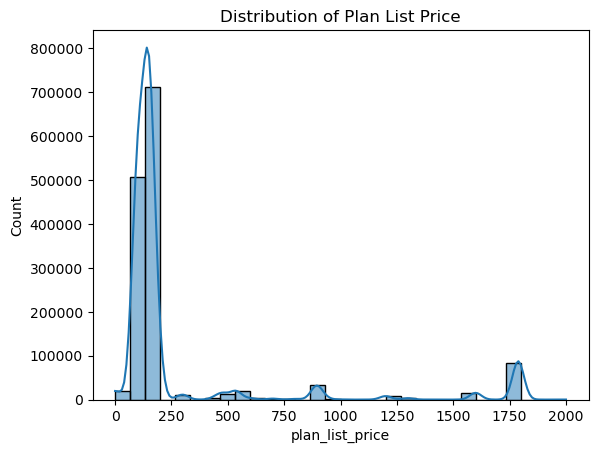

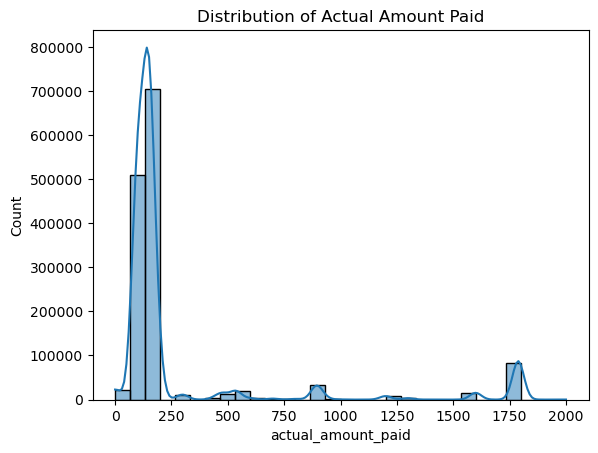

In [ ]:
# 4. Key Variables Distribution 

# Categorical variables distribution

# print cancellation distribution
print("\nCancellation distribution:")
print(transactions['is_cancel'].value_counts())

# print auto-renew distribution
print("\nAuto-renew distribution:")
print(transactions['is_auto_renew'].value_counts())

# print payment method distribution (top 10)
print("\nPayment method distribution (top 10):")
print(transactions['payment_method_id'].value_counts().head(10))


# plot cancellation distribution
sns.countplot(x='is_cancel', data=transactions)
plt.title("Cancellation Distribution")
plt.show()

# plot auto-renew distribution
sns.countplot(x='is_auto_renew', data=transactions)
plt.title("Auto Renew Distribution")
plt.show()

# plot payment method distribution (top 10)
top_methods = transactions['payment_method_id'].value_counts().head(10).index
sns.countplot(
    y='payment_method_id',
    data=transactions[transactions['payment_method_id'].isin(top_methods)],
    order=top_methods
)
plt.title("Top 10 Payment Methods")
plt.show()


# Numerical variables distribution

# print payment plan days distribution
print("\nPayment plan days distribution:")

# print plan list price distribution
print("\nPlan list price distribution:")
print(transactions['plan_list_price'].describe())

# print actual amount paid distribution
print("\nActual amount paid distribution:")
print(transactions['actual_amount_paid'].describe())

# plot payment plan days
sns.histplot(transactions['payment_plan_days'], bins=30, kde=True)
plt.title("Distribution of Payment Plan Days")
plt.show()

# plot list price
sns.histplot(transactions['plan_list_price'], bins=30, kde=True)
plt.title("Distribution of Plan List Price")
plt.show()

# plot actual amount paid
sns.histplot(transactions['actual_amount_paid'], bins=30, kde=True)
plt.title("Distribution of Actual Amount Paid")
plt.show()


Transactions initial EDA note: multiple transactions per user; 
no duplicated rows; cancellation and auto-renew seem relevant for churn; payment variables show different values across transactions

### 2.4. USER LOGS INITIAL EDA

In [56]:
# 1. Load user_logs_v2.csv dataset
user_logs = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/user_logs_v2.csv")

In [61]:
# 2. Dataset Structure
print("Dataset info:")
user_logs.info()

print(f"\nDataset shape: {user_logs.shape}")

print(f"\nDataset columns: {list(user_logs.columns)}")

print(f"\nDataset datatypes:\n{user_logs.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(user_logs.nunique())

# print dataset unique values per column (limited to avoid overload)
print("\nUnique values in each column (sample):")
for col in user_logs.columns:
    unique_values = user_logs[col].unique()
    print(f"{col}: {unique_values[:5]}{'...' if len(unique_values) > 5 else ''}")

# identify numerical and categorical columns
numerical_cols = user_logs.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = user_logs.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {list(numerical_cols)}")
print(f"\nCategorical columns: {list(categorical_cols)}")

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
members.head()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 1.2+ GB

Dataset shape: (18396362, 9)

Dataset columns: ['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']

Dataset datatypes:
msno           object
date            int64
num_25          int64
num_50          int64
num_75          int64
num_985         int64
num_100         int64
num_unq         int64
total_secs    float64
dtype: object

Number of unique values in each column:
msno           1103894
date                31
num_25             743
num_50             356
num_75             193
num_9

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [63]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(user_logs.isnull().sum())

# check percentage of missing values in each column
print("\nPercentage of missing values in each column:")
print((user_logs.isnull().sum() / len(user_logs) * 100).round(2))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {user_logs['msno'].duplicated().sum()}")

# check for duplicated rows
print(f"\nDuplicated rows in dataset: {user_logs.duplicated().sum()}")

# statistical summary only for true numerical variables
numerical_cols = ['num_25','num_50','num_75','num_985','num_100','num_unq','total_secs']

print("\nStatistical summary (numerical variables only):")
print(user_logs[numerical_cols].describe())

# check min and max values for key columns
print("\nMin and max values:")
print(user_logs[numerical_cols].agg(['min', 'max']))


Number of missing values in each column:
msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64

Percentage of missing values in each column:
msno          0.0
date          0.0
num_25        0.0
num_50        0.0
num_75        0.0
num_985       0.0
num_100       0.0
num_unq       0.0
total_secs    0.0
dtype: float64

Duplicated values in msno column: 17292468

Duplicated rows in dataset: 0

Statistical summary (numerical variables only):
             num_25        num_50        num_75       num_985       num_100  \
count  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07   
mean   6.191401e+00  1.508789e+00  9.413759e-01  1.079905e+00  3.028246e+01   
std    1.342827e+01  3.908539e+00  1.924840e+00  3.518409e+00  4.203641e+01   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+


Total seconds distribution:
count    1.839636e+07
mean     7.904814e+03
std      1.013632e+04
min      1.000000e-03
25%      1.959944e+03
50%      4.582990e+03
75%      9.848441e+03
max      9.194059e+06
Name: total_secs, dtype: float64

Unique songs distribution:
count    1.839636e+07
mean     2.903615e+01
std      3.219866e+01
min      1.000000e+00
25%      8.000000e+00
50%      1.800000e+01
75%      3.800000e+01
max      4.925000e+03
Name: num_unq, dtype: float64

Playback behavior distribution:
             num_25        num_50        num_75       num_985       num_100
count  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07
mean   6.191401e+00  1.508789e+00  9.413759e-01  1.079905e+00  3.028246e+01
std    1.342827e+01  3.908539e+00  1.924840e+00  3.518409e+00  4.203641e+01
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  7.000000e+00
50%    2.000000e+00  1.000000e+00  0.00

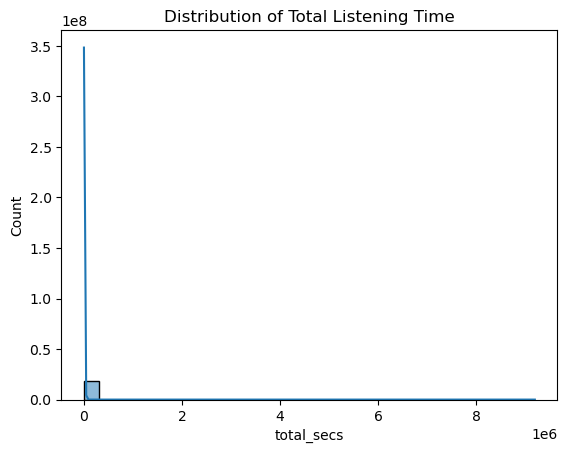

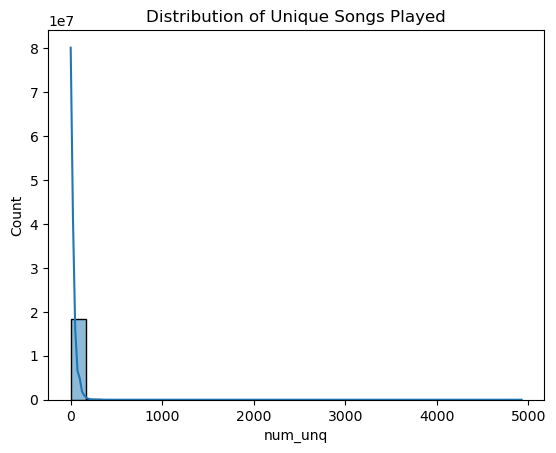

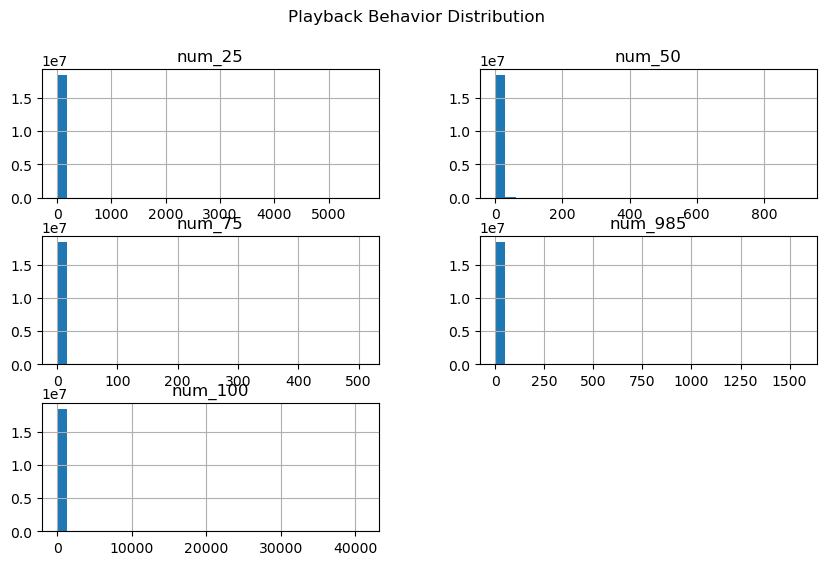

In [65]:
# 4. Key Variables Distribution 

# Numerical variables distribution

# print engagement variables distribution
print("\nTotal seconds distribution:")
print(user_logs['total_secs'].describe())

print("\nUnique songs distribution:")
print(user_logs['num_unq'].describe())

print("\nPlayback behavior distribution:")
print(user_logs[['num_25','num_50','num_75','num_985','num_100']].describe())


# plot total listening time
sns.histplot(user_logs['total_secs'], bins=30, kde=True)
plt.title("Distribution of Total Listening Time")
plt.show()

# plot unique songs
sns.histplot(user_logs['num_unq'], bins=30, kde=True)
plt.title("Distribution of Unique Songs Played")
plt.show()

# plot playback behavior
user_logs[['num_25','num_50','num_75','num_985','num_100']].hist(bins=30, figsize=(10,6))
plt.suptitle("Playback Behavior Distribution")
plt.show()

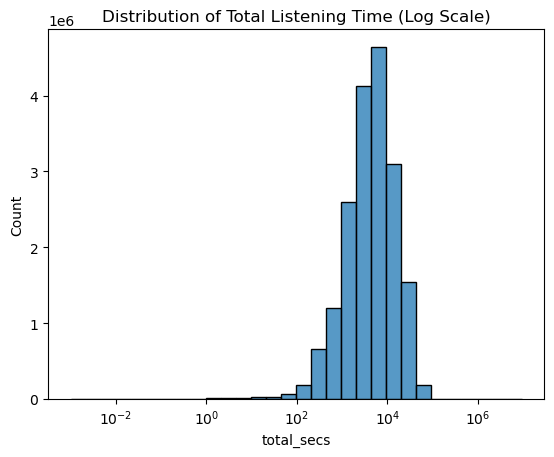

In [67]:
sns.histplot(user_logs['total_secs'], bins=30, log_scale=True)
plt.title("Distribution of Total Listening Time (Log Scale)")
plt.show()

User_logs initial EDA note: multiple records per user; no duplicated rows; user activity varies, with many low values and some very high engagement.